# Неделя 4. Вторник
## Обучение без учителя
### Кластеризация текстов

In [1]:
import numpy as np
import pandas as pd
import re
import string
from collections import defaultdict
from sklearn import metrics
from time import time
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups #набор данных 20 групп новостей
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

import sklearn
sklearn.set_config(transform_output='pandas')

In [23]:
# Импорты, необходимые для работы примера:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

# Задаём поднабор тем из корпуса 20 Newsgroups.
# Из 20 доступных групп берём только 4 выбранные категории.
categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

# Загружаем данные.
# remove=("headers", "footers", "quotes") — удаляет заголовки писем, подписи и цитаты,
#   чтобы модель не «читерила» на метаданных и работала по содержанию текста.
# subset="all" — берём и train, и test части набора.
# categories=categories — фильтруем только указанные выше 4 категории.
# shuffle=True — перемешиваем документы.
# random_state=42 — фиксируем «случайность» для воспроизводимых результатов.
dataset = fetch_20newsgroups(
    remove=("headers", "footers", "quotes"),
    subset="all",
    categories=categories,
    shuffle=True,
    random_state=42,
)

# Целевые метки (класс каждой новости) в виде целых индексов, соответствующих dataset.target_names.
labels = dataset.target

# np.unique(..., return_counts=True) вернёт отсортированный массив уникальных меток
# и количество документов в каждой из них.
unique_labels, category_sizes = np.unique(labels, return_counts=True)

# Число уникальных классов — фактическое количество категорий в поднаборе.
true_k = unique_labels.shape[0]

# Выводим краткую сводку: сколько документов и сколько категорий.
print(f"{len(dataset.data)} documents - {true_k} categories")

3387 documents - 4 categories


In [24]:
dataset.data[1]

"\nBy '8 grey level images' you mean 8 items of 1bit images?\nIt does work(!), but it doesn't work if you have more than 1bit\nin your screen and if the screen intensity is non-linear.\n\nWith 2 bit per pixel; there could be 1*c_1 + 4*c_2 timing,\nthis gives 16 levels, but they are linear if screen intensity is\nlinear.\nWith 1*c_1 + 2*c_2 it works, but we have to find the best\ncompinations -- there's 10 levels, but 16 choises; best 10 must be\nchosen. Different compinations for the same level, varies a bit, but\nthe levels keeps their order.\n\nReaders should verify what I wrote... :-)"

In [4]:
#Оценить качество кластеризации по нескольким метрикам

evaluations = []
evaluations_std = []

### функция проверки

def fit_and_evaluate(km, X, name=None, n_runs=5):
    """
    Обучает кластеризатор km на признаках X n_runs раз с разными seed'ами,
    считает среднее и std по времени обучения и метрикам,
    печатает сводку и кладёт результаты в глобальные списки evaluations/evaluations_std.

    ПРИМЕЧАНИЕ: функция использует истинные метки `labels` из внешней области
    (должны быть определены заранее: например, из 20 Newsgroups).
    """

    # Если имя не передали — берём имя класса оценивателя (например, "KMeans")
    name = km.__class__.__name__ if name is None else name

    train_times = []
    scores = defaultdict(list)  # по ключу-имени метрики хранится список результатов по всем запускам

    for seed in range(n_runs):
        # Фиксируем источник случайности для воспроизводимости текущего прогона.
        # Важно: у оценивателя должен быть параметр random_state; иначе set_params бросит ошибку.
        km.set_params(random_state=seed)

        # Обучаем и замеряем время fit
        t0 = time()
        km.fit(X)  # после fit у большинства кластеризаторов появляется атрибут km.labels_
        train_times.append(time() - t0)

        # ===== Внешние (supervised) метрики — требуют истинных меток `labels` =====
        # Homogeneity: каждый кластер содержит объекты в основном одного класса.
        scores["Homogeneity"].append(metrics.homogeneity_score(labels, km.labels_))
        # Completeness: объекты одного класса попадают в один кластер.
        scores["Completeness"].append(metrics.completeness_score(labels, km.labels_))
        # V-measure: гармоническое среднее Homogeneity и Completeness.
        scores["V-measure"].append(metrics.v_measure_score(labels, km.labels_))
        # Adjusted Rand Index: скорректированная по случайности похожесть разбиений.
        scores["Adjusted Rand-Index"].append(
            metrics.adjusted_rand_score(labels, km.labels_)
        )

        # ===== Внутренняя (unsupervised) метрика =====
        # Коэффициент силуэта: насколько кластеры компактны и разделены ([-1, 1], выше — лучше).
        # sample_size=2000 ускоряет расчёт на больших наборах; если выборка меньше — будет использована вся выборка.
        scores["Silhouette Coefficient"].append(
            metrics.silhouette_score(X, km.labels_, sample_size=2000)
        )

    # Время обучения -> в numpy для удобства среднего/ст.отклонения
    train_times = np.asarray(train_times)

    print(f"clustering done in {train_times.mean():.2f} ± {train_times.std():.2f} s ")

    # Словари со средними значениями и со стандартными отклонениями (хранятся отдельно)
    evaluation = {
        "estimator": name,
        "train_time": train_times.mean(),
    }
    evaluation_std = {
        "estimator": name,
        "train_time": train_times.std(),
    }

    # Считаем mean±std по каждой метрике за n_runs и печатаем
    for score_name, score_values in scores.items():
        mean_score, std_score = np.mean(score_values), np.std(score_values)
        print(f"{score_name}: {mean_score:.3f} ± {std_score:.3f}")
        evaluation[score_name] = mean_score
        evaluation_std[score_name] = std_score

    # Копим результаты всех моделей/настроек — удобно потом превратить в DataFrame и сравнить
    evaluations.append(evaluation)
    evaluations_std.append(evaluation_std)

### 1. Предварительная очистка данных

In [5]:
# Функция очистки текста

def clean(text):
    text = text.lower() # нижний регистр
    text = re.sub(r'http\S+', " ", text) # удаляем ссылки
    text = re.sub(r'@\w+',' ',text) # удаляем упоминания пользователей
    text = re.sub(r'#\w+', ' ', text) # удаляем хэштеги
    text = re.sub(r'\d+', ' ', text) # удаляем числа
    text = text.translate(str.maketrans('', '', string.punctuation))
    # text = re.sub(r'<.*?>',' ', text) #
    return text

cleaned_text = []

for text in dataset.data:
    cleaned_text.append(clean(text))

In [6]:
cleaned_text[1]

'\nby   grey level images you mean   items of  bit images\nit does work but it doesnt work if you have more than  bit\nin your screen and if the screen intensity is nonlinear\n\nwith   bit per pixel there could be  c    c  timing\nthis gives   levels but they are linear if screen intensity is\nlinear\nwith  c    c  it works but we have to find the best\ncompinations  theres   levels but   choises best   must be\nchosen different compinations for the same level varies a bit but\nthe levels keeps their order\n\nreaders should verify what i wrote '

### 2. Лемматизация

In [7]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [8]:
# create lemmatizer object
wn_lemmatizer = WordNetLemmatizer()

# Пример
wn_lemmatizer.lemmatize('oranges', pos='n') # pos = 'n'(noun) - лемматизация именно существительных, можно включить другие части речи

'orange'

In [9]:
lemmatized_text = []
for tweet in cleaned_text:
    lemmatized_text.append(' '.join([wn_lemmatizer.lemmatize(word) for word in tweet.split()]))

### 3. Токенизация

In [10]:
# Create and apply tokenizer

reg_tokenizer = RegexpTokenizer('\w+')

tokenized_text = reg_tokenizer.tokenize_sents(lemmatized_text)

<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-1747990821.py:3: SyntaxWarning: invalid escape sequence '\w'
  reg_tokenizer = RegexpTokenizer('\w+')


### 4. Удаление стоп-слов

In [11]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
# стоп-слова надо кэшировать
sw = stopwords.words('english')

clean_tokenized_text = []
for i, element in enumerate(tokenized_text):
    clean_tokenized_text.append(' '.join([word for word in element if word not in sw]))

### 5. Векторизация текста (text to matrix)

In [13]:
vectorizer = TfidfVectorizer(
    max_df=0.5, #выкинуть слова, встречающиеся в более чем 50%
    min_df=5, #убрать слова, которые встречаются меньше чем в 5 документах
    stop_words="english",
)
t0 = time()
X_tfidf = vectorizer.fit_transform(clean_tokenized_text)

print(f"vectorization done in {time() - t0:.3f} s")
print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

vectorization done in 0.362 s
n_samples: 3387, n_features: 6637


* 6637 токенов в нашем словаре

In [14]:
X_tfidf =  pd.DataFrame(data=X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

X_tfidf

,aa,ab,abandon,abandoned,abbreviation,abc,ability,able,aboard,abomination,...,zbuffer,zealand,zero,zeus,zillion,zip,zone,zoom,zooming,zyxel
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.069584,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3385,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
kmeans = KMeans(
    n_clusters=true_k,
)

fit_and_evaluate(kmeans, X_tfidf, name="KMeans\non tf-idf vectors")

clustering done in 2.41 ± 0.68 s 
Homogeneity: 0.251 ± 0.015
Completeness: 0.295 ± 0.029
V-measure: 0.271 ± 0.020
Adjusted Rand-Index: 0.159 ± 0.013
Silhouette Coefficient: 0.008 ± 0.001


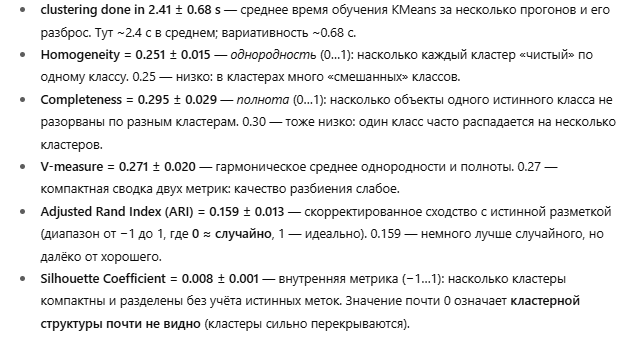

### 6. Понижение размерности

In [16]:
svd = make_pipeline(TruncatedSVD(n_components=100), Normalizer(copy=False)) #понижает размерность разреженной TF-IDF матрицы до 100 измерений.
# lsa = TruncatedSVD(n_components=100)
t0 = time()
X_svd = svd.fit_transform(X_tfidf)
explained_variance = svd[0].explained_variance_ratio_.sum()

print(f"SVD done in {time() - t0:.3f} s")
print(f"Explained variance of the SVD: {explained_variance * 100:.1f}%")

SVD done in 7.526 s
Explained variance of the SVD: 20.5%


In [17]:
X_svd.shape

(3387, 100)

In [18]:
kmeans = KMeans(
    n_clusters=true_k,
)

fit_and_evaluate(kmeans, X_svd, name="KMeans\nwith LSA on tf-idf vectors")

clustering done in 0.12 ± 0.03 s 
Homogeneity: 0.348 ± 0.009
Completeness: 0.372 ± 0.006
V-measure: 0.360 ± 0.006
Adjusted Rand-Index: 0.290 ± 0.014
Silhouette Coefficient: 0.030 ± 0.001


In [19]:
original_space_centroids = svd[0].inverse_transform(kmeans.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(true_k):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()

Cluster 0: space wa launch orbit mission shuttle moon year cost satellite 
Cluster 1: dont think people im ha like know say time right 
Cluster 2: wa god christian jesus people say believe bible think religion 
Cluster 3: file image thanks graphic program format know help use email 


### 7. Соединение в пайплайн Векторизации и понижения размерности

In [20]:
from sklearn.feature_extraction.text import HashingVectorizer, CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

svd_vectorizer = make_pipeline(
    HashingVectorizer(stop_words="english", n_features=50_000),
    TfidfTransformer(), # Нужен для нормировки результатов с HashingVectorizer
    TruncatedSVD(n_components=100, random_state=0),
    Normalizer(copy=False),
)

t0 = time()
X_hashed_lsa = svd_vectorizer.fit_transform(dataset.data)
print(f"vectorization done in {time() - t0:.3f} s")

vectorization done in 7.348 s


In [21]:
fit_and_evaluate(kmeans, X_hashed_lsa, name="KMeans\nwith LSA on hashed vectors")

clustering done in 0.18 ± 0.11 s 
Homogeneity: 0.386 ± 0.013
Completeness: 0.429 ± 0.025
V-measure: 0.406 ± 0.019
Adjusted Rand-Index: 0.327 ± 0.019
Silhouette Coefficient: 0.029 ± 0.002


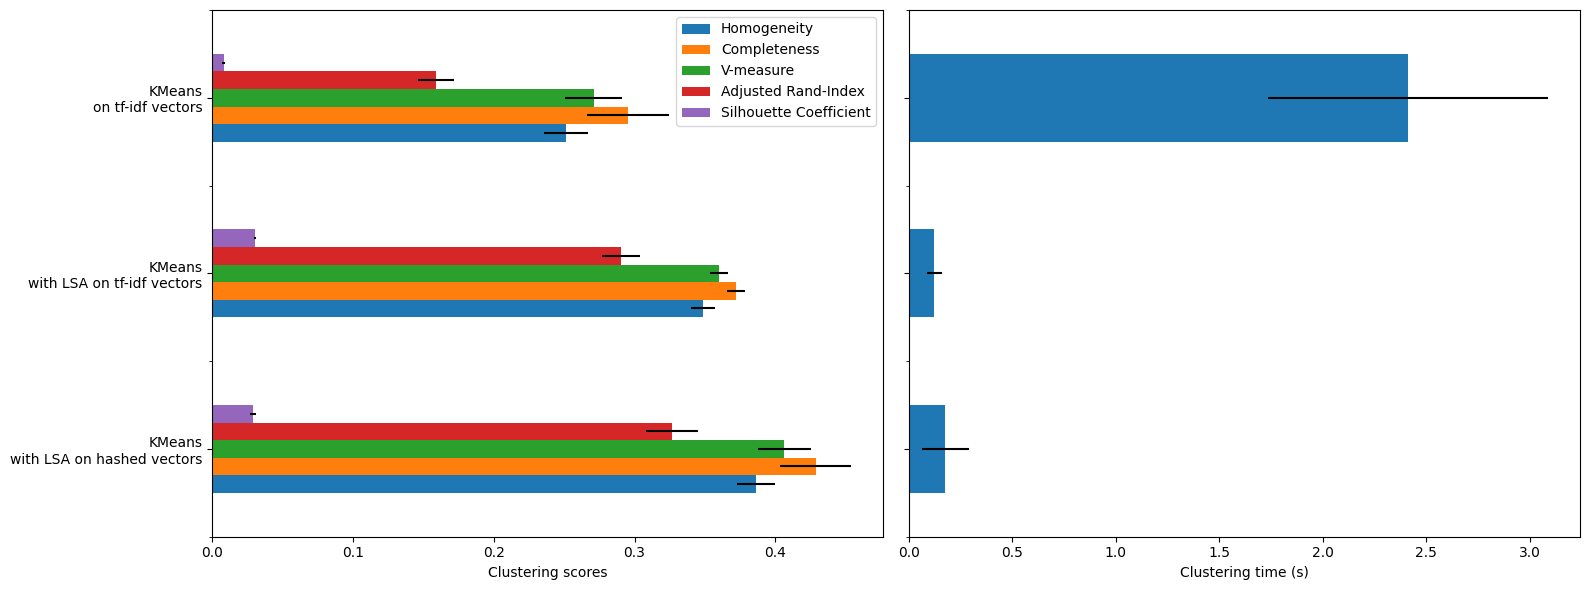

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(16, 6), sharey=True)

df = pd.DataFrame(evaluations[::-1]).set_index("estimator")
df_std = pd.DataFrame(evaluations_std[::-1]).set_index("estimator")

df.drop(
    ["train_time"],
    axis="columns",
).plot.barh(ax=ax0, xerr=df_std)
ax0.set_xlabel("Clustering scores")
ax0.set_ylabel("")

df["train_time"].plot.barh(ax=ax1, xerr=df_std["train_time"])
ax1.set_xlabel("Clustering time (s)")
plt.tight_layout()